# Why Do Some Students Fail Despite High Attendance?

## Project Overview
This project explores student performance data to understand why some students fail
even when they have high attendance rates. The goal is to move beyond assumptions
and identify hidden factors such as consistency, assessment performance, and behavioral patterns.

## Key Questions
- Do students with high attendance always pass?
- What differentiates high-attendance students who pass from those who fail?
- Is consistency more important than average performance?
- Can we identify distinct student performance profiles?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8')

In [6]:
path_to_data = Path(r'C:\Users\konta\Documents\Data_Analysis_Projects\Student_Performance_Analysis\data\student_info.csv')
df = pd.read_csv(path_to_data)

In [7]:
df

,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S996,Student_996,Female,15,10,76,75,55,94.127440,Bachelor's,2.212263,Yes,Free or reduced,No,Fail
996,S997,Student_997,Female,17,12,83,68,98,86.911592,Bachelor's,3.552898,No,Free or reduced,Yes,Fail
997,S998,Student_998,Other,16,10,60,77,92,80.139645,PhD,2.400027,No,Free or reduced,No,Pass
998,S999,Student_999,Other,17,9,94,66,97,88.069619,PhD,4.713490,No,Free or reduced,Yes,Pass


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1000 non-null   object 
 1   name              1000 non-null   object 
 2   gender            1000 non-null   object 
 3   age               1000 non-null   int64  
 4   grade_level       1000 non-null   int64  
 5   math_score        1000 non-null   int64  
 6   reading_score     1000 non-null   int64  
 7   writing_score     1000 non-null   int64  
 8   attendance_rate   1000 non-null   float64
 9   parent_education  1000 non-null   object 
 10  study_hours       1000 non-null   float64
 11  internet_access   1000 non-null   object 
 12  lunch_type        1000 non-null   object 
 13  extra_activities  1000 non-null   object 
 14  final_result      1000 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 117.3+ KB


#### Initial data inspection showed no missing values. However, additional validation and preparation steps were still performed to ensure data quality and analytical consistency.

In [9]:
df.describe()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,15.999000,10.473000,75.165000,74.293000,75.150000,89.879179,2.978380
std,0.817109,1.136029,14.304349,14.312652,14.395094,5.725007,1.167780
min,15.000000,9.000000,50.000000,50.000000,50.000000,80.000614,1.015673
25%,15.000000,9.000000,63.000000,62.000000,63.000000,84.971772,1.955287
50%,16.000000,10.000000,75.000000,74.000000,75.000000,89.980889,2.962665
75%,17.000000,12.000000,88.000000,86.000000,88.000000,94.629778,3.994360
max,17.000000,12.000000,99.000000,99.000000,99.000000,99.954988,4.997843


In [10]:
df.dtypes

student_id           object
name                 object
gender               object
age                   int64
grade_level           int64
math_score            int64
reading_score         int64
writing_score         int64
attendance_rate     float64
parent_education     object
study_hours         float64
internet_access      object
lunch_type           object
extra_activities     object
final_result         object
dtype: object

## Data Cleaning and Validation

The dataset was inspected for missing values, invalid ranges, and logical inconsistencies.
No data quality issues were identified, and no cleaning actions were required.
The dataset was therefore considered ready for analysis.


In [13]:
df['high_attendance'] = df['attendance_rate'] >= 85

A high-attendance indicator was created to distinguish students with attendance rates of 85% or higher, a commonly used academic threshold.

## Exploratory Analysis

In [14]:
df

,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result,high_attendance
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail,True
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass,True
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail,True
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass,True
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S996,Student_996,Female,15,10,76,75,55,94.127440,Bachelor's,2.212263,Yes,Free or reduced,No,Fail,True
996,S997,Student_997,Female,17,12,83,68,98,86.911592,Bachelor's,3.552898,No,Free or reduced,Yes,Fail,True
997,S998,Student_998,Other,16,10,60,77,92,80.139645,PhD,2.400027,No,Free or reduced,No,Pass,False
998,S999,Student_999,Other,17,9,94,66,97,88.069619,PhD,4.713490,No,Free or reduced,Yes,Pass,True


In [25]:
df_high_atten_pass = df[(df['high_attendance']) & (df['final_result'] == 'Pass')]

In [27]:
df_high_atten_fail = df[(df['high_attendance']) & (df['final_result'] == 'Fail')]

In [29]:
print(f'High attendance + Pass: {len(df_high_atten_pass)}')
print(f'High attendance + Fail: {len(df_high_atten_fail)}')

High attendance + Pass: 394
High attendance + Fail: 353


In [34]:
total = len(df_high_atten_pass) + len(df_high_atten_fail)

pass_rate = len(df_high_atten_pass) / total * 100
fail_rate = len(df_high_atten_fail) / total * 100

print(f'Pass Rate: {round(pass_rate, 2)} %')
print(f'Fail Rate: {round(fail_rate, 2)} %')

Pass Rate: 52.74 %
Fail Rate: 47.26 %


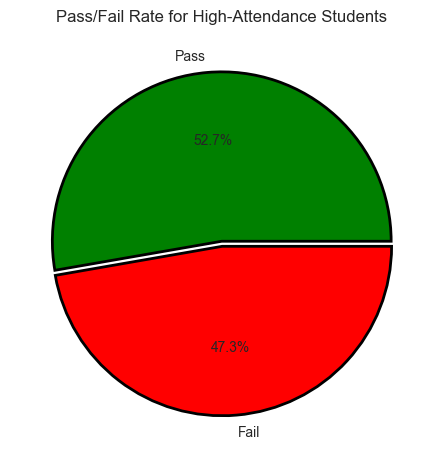

In [74]:
sizes = [pass_rate, fail_rate]
labels = ['Pass', 'Fail']
colors = ['green', 'red']
explode = [0, 0.03]

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', colors=colors, shadow=False, startangle=0, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 2, 'antialiased': True})
plt.title('Pass/Fail Rate for High-Attendance Students')
plt.show()

### High Attendance Is Not a Guarantee of Success

Among students with high attendance (≥ 85%), 394 students passed while 353 failed.
This near-even split indicates that attendance alone is a weak predictor of academic success
and suggests that other factors play a significant role in student outcomes.


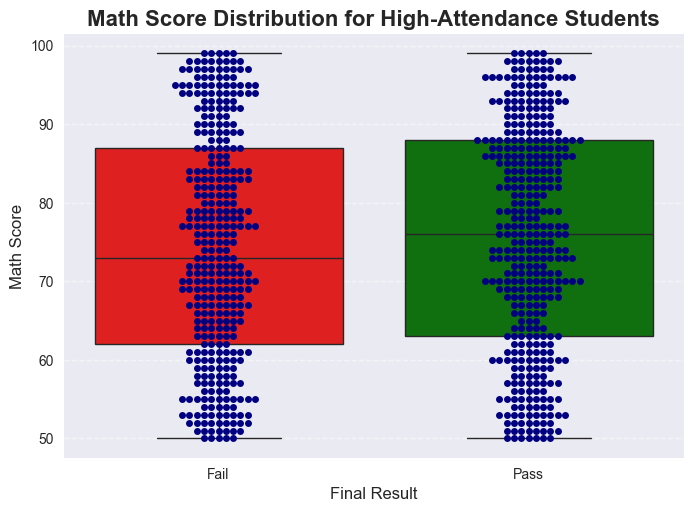

In [84]:
df_high = df[df['high_attendance']]

colors = ['green', 'red']

sns.boxplot(
    data=df_high,
    x='final_result',
    y='math_score',
    hue='final_result',  
    palette={'Pass':'green','Fail':'red'},
    dodge=False,         
    legend=False
)

sns.swarmplot(
    data=df_high,
    x='final_result',
    y='math_score',
    color='#000080', 
    size=5
)

plt.title('Math Score Distribution for High-Attendance Students', fontsize=16, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Math Score', fontsize=12)

sns.despine(trim=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


High-attendance students who failed show lower median math scores and greater variability, suggesting inconsistent mastery of core concepts.

In [85]:
df_high

,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result,high_attendance
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail,True
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass,True
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail,True
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass,True
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,S993,Student_993,Female,17,11,86,78,70,99.842713,Bachelor's,3.003506,No,Standard,Yes,Pass,True
993,S994,Student_994,Other,15,9,85,58,73,97.150612,High School,4.925686,No,Free or reduced,Yes,Fail,True
995,S996,Student_996,Female,15,10,76,75,55,94.127440,Bachelor's,2.212263,Yes,Free or reduced,No,Fail,True
996,S997,Student_997,Female,17,12,83,68,98,86.911592,Bachelor's,3.552898,No,Free or reduced,Yes,Fail,True


In [94]:
df_active_pass = df_high[(df_high['extra_activities'] == 'Yes') & (df_high['final_result'] == 'Pass')]

In [95]:
df_active_fail = df_high[(df_high['extra_activities'] == 'Yes') & (df_high['final_result'] == 'Fail')]

In [96]:
len(df_active_pass), len(df_active_fail)

(207, 190)